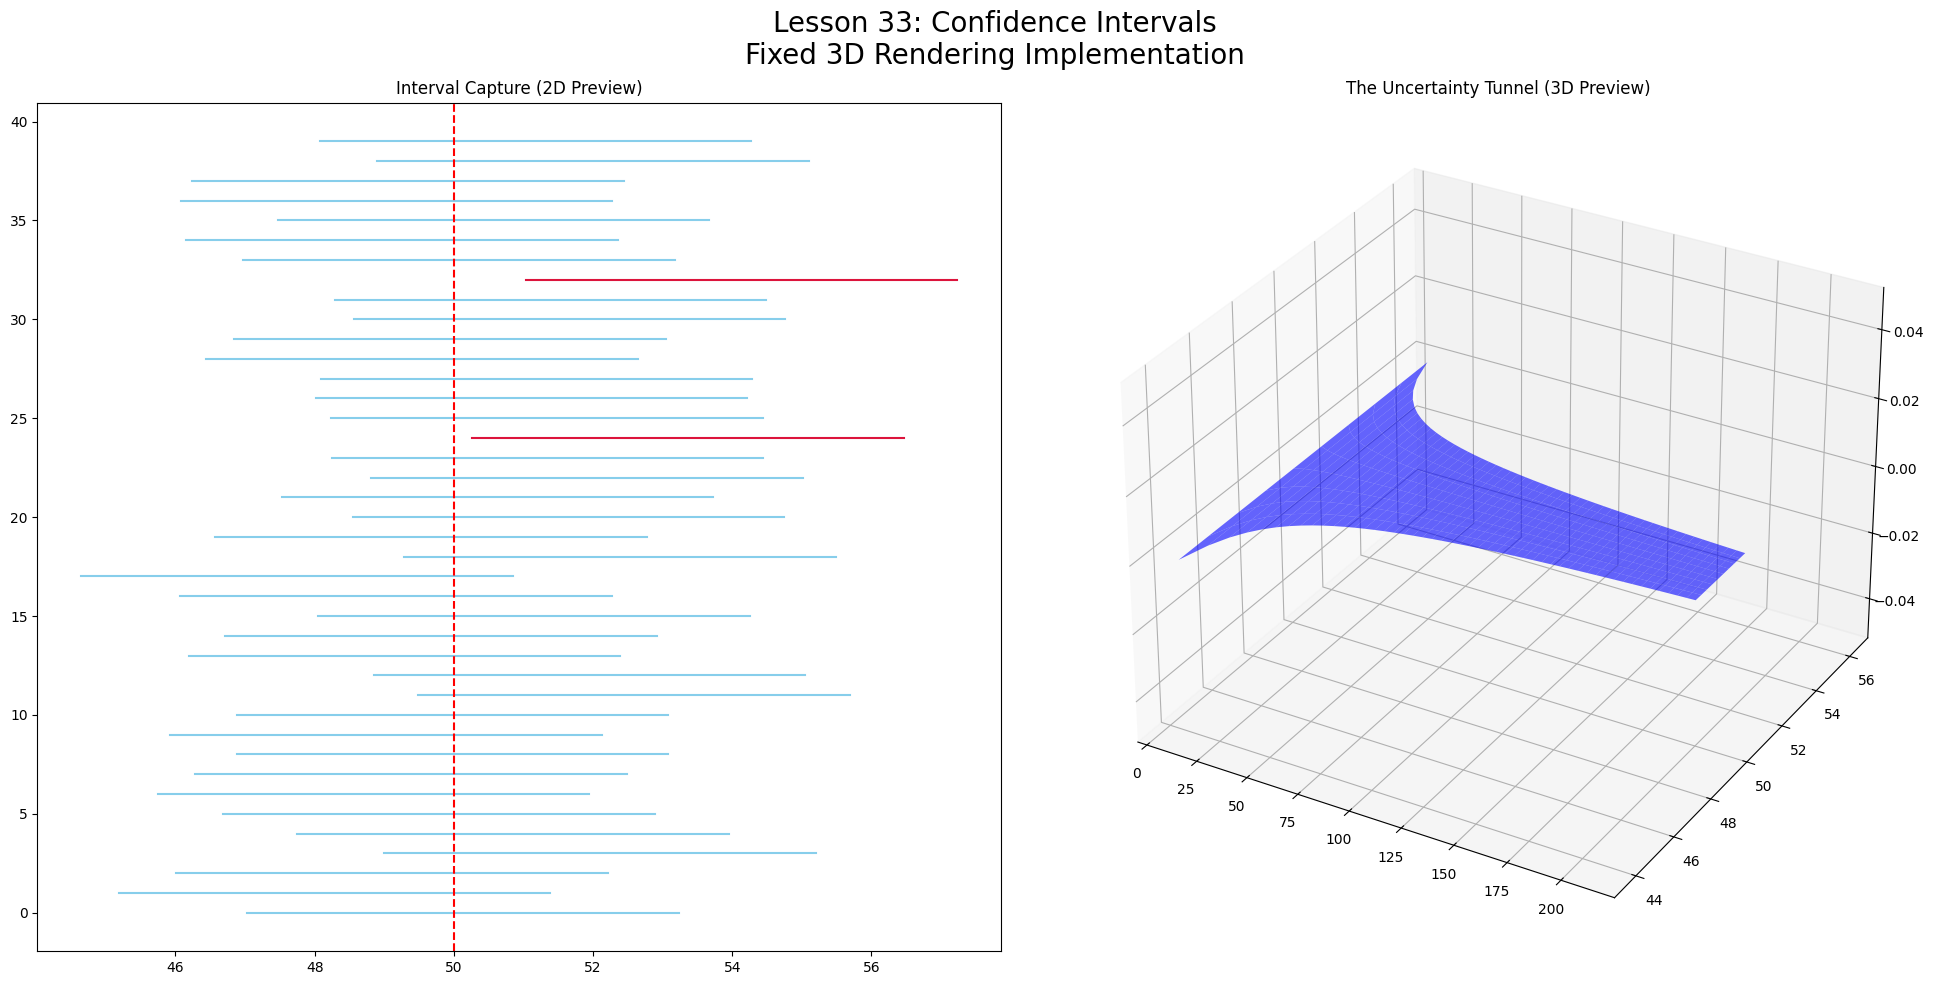

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from mpl_toolkits.mplot3d import Axes3D
import os

def run_confidence_intervals():
    # Assets yolu
    asset_path = '../../../assets'
    if not os.path.exists(asset_path): os.makedirs(asset_path)

    # 1. Popülasyon Parametreleri
    pop_mean = 50
    pop_std = 10
    n_samples = 100
    sample_size = 40
    confidence = 0.95

    # Veri Üretimi
    means = []
    intervals = []
    z_critical = stats.norm.ppf((1 + confidence) / 2)
    
    for _ in range(n_samples):
        sample = np.random.normal(pop_mean, pop_std, sample_size)
        x_bar = np.mean(sample)
        margin_of_error = z_critical * (pop_std / np.sqrt(sample_size))
        means.append(x_bar)
        intervals.append((x_bar - margin_of_error, x_bar + margin_of_error))

    # --- ASSET 1: 2D VISUALIZATION (Capture Plot) ---
    fig2d = plt.figure(figsize=(10, 12))
    ax2d = fig2d.add_subplot(111)
    
    hits = 0
    for i in range(n_samples):
        low, high = intervals[i]
        is_hit = low <= pop_mean <= high
        color = 'skyblue' if is_hit else 'crimson'
        if is_hit: hits += 1
        ax2d.plot([low, high], [i, i], color=color, lw=1.5)
        ax2d.plot(means[i], i, 'k.', markersize=3)

    ax2d.axvline(pop_mean, color='black', linestyle='--', lw=2, label=f'True Mean ({pop_mean})')
    ax2d.set_title(f"2D Confidence Intervals (95%)\nCapture Rate: {hits}/{n_samples}", fontsize=14)
    ax2d.legend()
    plt.savefig(f'{asset_path}/33_ci_2d.png', dpi=300)
    plt.close(fig2d)

    # --- ASSET 2: 3D VISUALIZATION (Fixed Uncertainty Tunnel) ---
    fig3d = plt.figure(figsize=(10, 8))
    ax3d = fig3d.add_subplot(111, projection='3d')
    
    sizes = np.linspace(10, 210, 50)
    errors = z_critical * (pop_std / np.sqrt(sizes))
    
    # 3D'de dolgu yerine yüzey (Surface) kullanarak tünel oluşturuyoruz
    S, V = np.meshgrid(sizes, np.linspace(-1, 1, 10))
    # Y ekseni değerlerini (hata paylarını) hesapla
    Y_vals = pop_mean + V * (z_critical * (pop_std / np.sqrt(S)))
    
    surf = ax3d.plot_surface(S, Y_vals, V*0, cmap='winter', alpha=0.5, edgecolor='none')
    ax3d.plot(sizes, [pop_mean]*len(sizes), 0, color='red', lw=3, label='Population Mean')
    
    ax3d.set_title("3D Confidence Tunnel: The Power of Sample Size")
    ax3d.set_xlabel("Sample Size (n)"); ax3d.set_ylabel("Confidence Range"); ax3d.set_zlabel("Density")
    plt.savefig(f'{asset_path}/33_ci_3d.png', dpi=300)
    plt.close(fig3d)

    # --- MASTER DASHBOARD ---
    master_fig = plt.figure(figsize=(20, 10))
    
    ax_l = master_fig.add_subplot(121)
    for i in range(min(40, n_samples)):
        low, high = intervals[i]
        color = 'skyblue' if low <= pop_mean <= high else 'crimson'
        ax_l.plot([low, high], [i, i], color=color)
    ax_l.axvline(pop_mean, color='red', ls='--')
    ax_l.set_title("Interval Capture (2D Preview)")

    ax_r = master_fig.add_subplot(122, projection='3d')
    ax_r.plot_surface(S, Y_vals, V*0, cmap='winter', alpha=0.6)
    ax_r.set_title("The Uncertainty Tunnel (3D Preview)")

    plt.suptitle(f"Lesson 33: Confidence Intervals\nFixed 3D Rendering Implementation", fontsize=20)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_confidence_intervals()